# Customer Churn Prediction

## Project Overview

Customer churn is one of the most important business problems faced by subscription-based companies. Acquiring new customers is generally more expensive than retaining existing ones.

The objective of this project is to predict customer churn using machine learning techniques and identify the factors that influence customer retention.

The project uses the IBM Telco Customer Churn dataset and applies data cleaning, exploratory data analysis, feature engineering, machine learning, and business interpretation.

## Objectives

- Identify factors associated with customer churn
- Build machine learning models to predict churn
- Compare model performance
- Generate actionable business recommendations

## Project Workflow

1. Data Understanding
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Train-Test Split
6. Logistic Regression
7. Random Forest
8. Model Comparison
9. ROC-AUC Analysis
10. Feature Importance
11. Business Recommendations
12. Conclusion

## 1. Data Understanding

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('C:/Users/prata/Desktop/Customer-Churn-Prediction/data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Dataset Overview

The dataset contains 7,043 customer records and 21 features.

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['TotalCharges'].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object

In [7]:
df['TotalCharges'].sample(20)

1297      402.5
5801     2425.4
5353     1393.6
2607      69.75
405     1468.75
4022      163.2
1161      31.35
2182    5873.75
5638      19.95
4977     469.65
5219       20.6
5705      19.65
506       851.8
2186      862.4
3517    7534.65
5779    3692.85
2818    2649.15
2365     1743.9
1895    5882.75
1308       1281
Name: TotalCharges, dtype: object

In [8]:
(df['TotalCharges'] == '' ).sum()

np.int64(0)

In [9]:
(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [10]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [11]:
df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


### Handling Blank Values in TotalCharges

The TotalCharges column contained 11 blank values corresponding to customers with zero tenure. Since these customers had not accumulated any charges, the blank values were replaced with 0 before converting the column to numeric format.

In [12]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', 0)

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [14]:
df['TotalCharges'].dtype

dtype('float64')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Data Cleaning

- Identified 11 blank values in TotalCharges.
- Replaced blanks with 0.
- The 11 blank values occurred for customers with zero tenure. Since these customers had not yet accumulated charges, blank values were replaced with 0 before converting the column to numeric format.
- Converted TotalCharges to float64.

In [16]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [17]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## 3. Exploratory Data Analysis

### Churn Distribution

The following chart shows the distribution of customers who churned and those who remained with the company.

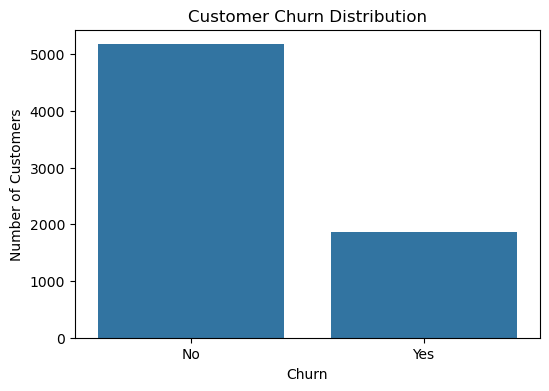

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Churn'
)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.savefig(
    'churn_distribution.png',
    bbox_inches='tight'
)

plt.show()

In [19]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [20]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [21]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize = 'index'
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [22]:
print(df['Contract'].dtype)
print(df['Churn'].dtype)

object
object


### Contract Type vs Churn

The following visualization compares customer churn across different contract types to understand how contract duration influences customer retention.

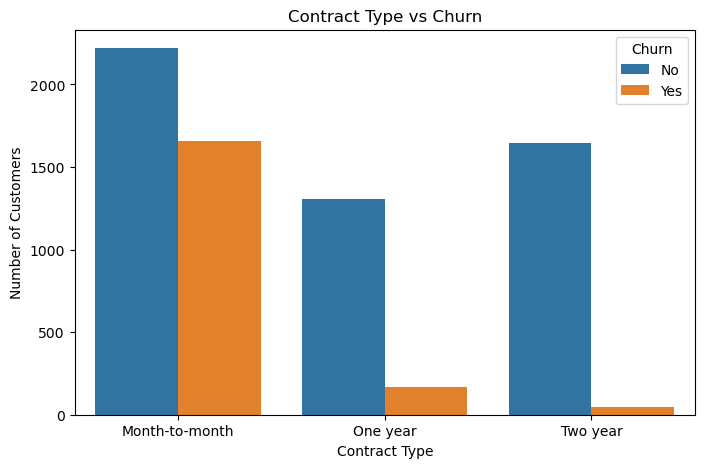

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.savefig(
    'contract_vs_churn.png',
    bbox_inches='tight'
)

plt.show()

In [24]:
df.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


### Tenure vs Churn

The following visualization compares the tenure distribution of customers who churned and customers who remained with the company.

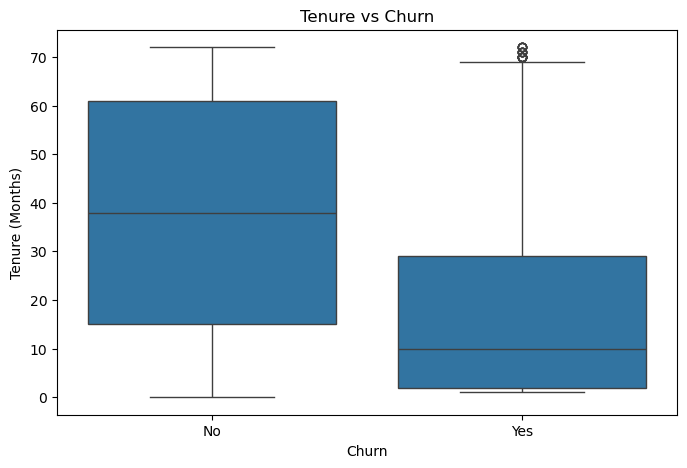

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.savefig(
    'tenure_vs_churn.png',
    bbox_inches='tight'
)

plt.show()

In [26]:
df.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


### Monthly Charges vs Churn

The following visualization compares monthly charges for customers who churned and customers who remained with the company.

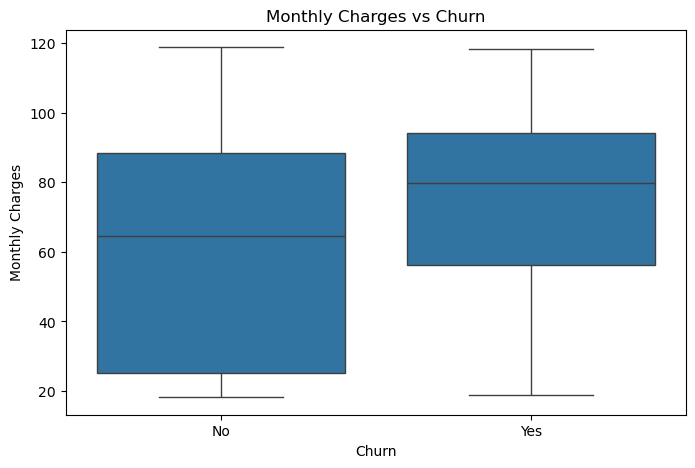

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.savefig(
    'monthly_charges_vs_churn.png',
    bbox_inches='tight'
)

plt.show()

## Key Insights

### Insight 1: Contract Type and Churn

Month-to-month customers exhibit the highest churn rate at 42.71%.

Customers on one-year and two-year contracts are significantly less likely to churn, with churn rates of 11.27% and 2.83% respectively.

This suggests that contract length is a strong predictor of customer retention.

### Insight 2: Customer Tenure and Churn

Customers who churn have a significantly lower average tenure (17.98 months) compared to customers who remain with the company (37.57 months).

This suggests that newer customers are at a higher risk of churning, while long-term customers are generally more loyal.

Although some long-tenure customers still churn, tenure appears to be a strong predictor of customer retention.

### Insight 3: Monthly Charges and Churn

Customers who churn have a higher average monthly charge (74.44) compared to customers who remain with the company (61.27).

This suggests that customers paying higher monthly fees were more likely to churn in this dataset.

Further investigation would be required to determine whether pricing directly influences churn or whether other customer characteristics contribute to this relationship.

## 4. Feature Engineering

Categorical variables were converted into numerical features using One-Hot Encoding.

The customerID column was removed because it does not contribute to churn prediction.

The target variable (Churn) was encoded as:

- No = 0
- Yes = 1

### Final Dataset

After one-hot encoding, the dataset contained:

- 7,043 observations
- 30 input features
- 1 target variable (Churn)

In [28]:
df_model = df.copy()

In [29]:
df_model = df_model.drop('customerID', axis = 1)

In [30]:
df_model.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [31]:
df_model['Churn'] = df_model['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [32]:
df_model['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [33]:
df_model = pd.get_dummies(
    df_model,
    drop_first = True
)

In [34]:
df_model.shape

(7043, 31)

In [35]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   gender_Male                            7043 non-null   bool   
 6   Partner_Yes                            7043 non-null   bool   
 7   Dependents_Yes                         7043 non-null   bool   
 8   PhoneService_Yes                       7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10  MultipleLines_Yes                      7043 non-null   bool   
 11  Inte

In [36]:
X = df_model.drop('Churn', axis = 1)
y = df_model['Churn']

In [37]:
X.shape

(7043, 30)

In [38]:
y.shape

(7043,)

## 5. Train-Test Split

The dataset was divided into training and testing sets.

- Training Set: 80%
- Testing Set: 20%

Stratified sampling was used to preserve the churn distribution.

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [40]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 30)
(1409, 30)
(5634,)
(1409,)


## 6. Logistic Regression

A Logistic Regression model was trained as the baseline model for churn prediction.

In [41]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter = 1000
)

model.fit(X_train, y_train)

C:\Users\prata\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [42]:
y_pred = model.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8041163946061036

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [45]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[925 110]
 [166 208]]


### Note on Model Convergence

The initial Logistic Regression model generated a convergence warning because the features were not scaled. To address this issue, feature scaling was applied using StandardScaler and the model was retrained. The scaled Logistic Regression model achieved improved performance and was selected as the final model.

### Logistic Regression Performance

A Logistic Regression model was trained to predict customer churn.

### Results

- Accuracy: 80.4%
- Precision: 65%
- Recall: 56%
- F1 Score: 60%

The model correctly identified 208 out of 374 customers who actually churned.

While overall accuracy is strong, the model missed 166 churning customers, indicating that further improvements could be made through feature engineering, scaling, and more advanced machine learning algorithms.

In [46]:
from sklearn.preprocessing import StandardScaler

scaler  = StandardScaler()

In [47]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [48]:
from sklearn.linear_model import LogisticRegression

model_scaled = LogisticRegression(
    max_iter = 5000,
    random_state=42
)

model_scaled.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [49]:
y_pred_scaled = model_scaled.predict(
    X_test_scaled
)

In [50]:
from sklearn.metrics import accuracy_score

print(
    accuracy_score(
        y_test,
        y_pred_scaled
    )
)

0.8069552874378992


In [51]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_scaled
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## 7. Random Forest

### Random Forest Findings

Although Random Forest is a powerful ensemble algorithm, it performed slightly worse than Logistic Regression on this dataset.

Therefore, Logistic Regression was selected as the final model.

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [53]:
y_pred_rf = rf_model.predict(X_test)

In [54]:
from sklearn.metrics import accuracy_score

print(
    accuracy_score(
        y_test,
        y_pred_rf
    )
)

0.7849538679914834


In [55]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



In [56]:
from sklearn.metrics import confusion_matrix

print(
    confusion_matrix(
        y_test,
        y_pred_rf
    )
)

[[920 115]
 [188 186]]


## 8. Model Comparison

The performance of Logistic Regression and Random Forest models was compared using accuracy, precision, recall, and F1-score.

| Model | Accuracy | Precision | Recall | F1 Score |
|---------|---------|---------|---------|---------|
| Logistic Regression | 80.4% | 65% | 56% | 60% |
| Logistic Regression (Scaled) | 80.7% | 66% | 57% | 61% |
| Random Forest | 78.5% | 62% | 50% | 55% |

Scaled Logistic Regression achieved the best overall performance and was selected as the final model.

## 9. ROC-AUC Analysis

ROC-AUC (Receiver Operating Characteristic - Area Under Curve) measures the model's ability to distinguish between churned and non-churned customers.

An ROC-AUC score of:

- 0.5 indicates random guessing
- 0.7–0.8 indicates acceptable discrimination
- 0.8–0.9 indicates excellent discrimination
- Above 0.9 indicates outstanding discrimination

The ROC-AUC score was calculated for the selected Logistic Regression model.

In [57]:
from sklearn.metrics import roc_auc_score

y_prob = model_scaled.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.841778397788628


In [58]:
import os

os.makedirs('images', exist_ok=True)

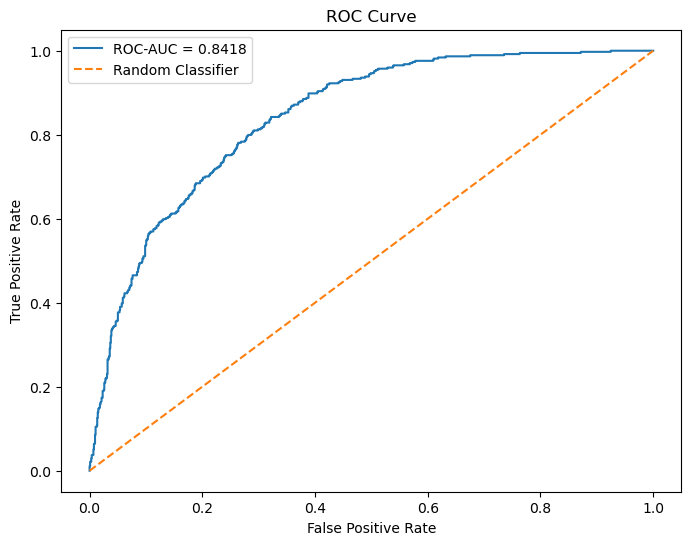

In [59]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

# Create figure
plt.figure(figsize=(8, 6))

# Plot ROC curve
plt.plot(
    fpr,
    tpr,
    label=f'ROC-AUC = {roc_auc:.4f}'
)

# Plot random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

# Show legend
plt.legend()

# Save image for GitHub
plt.savefig(
    'images/roc_curve.png',
    bbox_inches='tight',
    dpi=300
)

# Display chart
plt.show()

### ROC-AUC Interpretation

The Logistic Regression model achieved a ROC-AUC score of 0.8418.

This indicates that the model has strong discriminatory power and can effectively distinguish between customers who churn and customers who remain with the company.

Since the ROC-AUC score is greater than 0.8, the model demonstrates excellent classification performance and is suitable for identifying customers at risk of churn.

## 10. Feature Importance

The Random Forest model identified the following as the most influential features:

1. TotalCharges
2. tenure
3. MonthlyCharges
4. PaymentMethod_Electronic check
5. InternetService_Fiber optic

The results confirm the findings from exploratory data analysis, indicating that customer tenure, charges, contract type, and service-related factors play major roles in customer churn.

In [60]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,TotalCharges,0.191149
1,tenure,0.174795
2,MonthlyCharges,0.169026
28,PaymentMethod_Electronic check,0.039095
10,InternetService_Fiber optic,0.037259
25,Contract_Two year,0.029864
13,OnlineSecurity_Yes,0.029774
4,gender_Male,0.028501
26,PaperlessBilling_Yes,0.025097
19,TechSupport_Yes,0.023192


### Feature Importance Visualization

The following chart shows the most influential features identified by the Random Forest model.

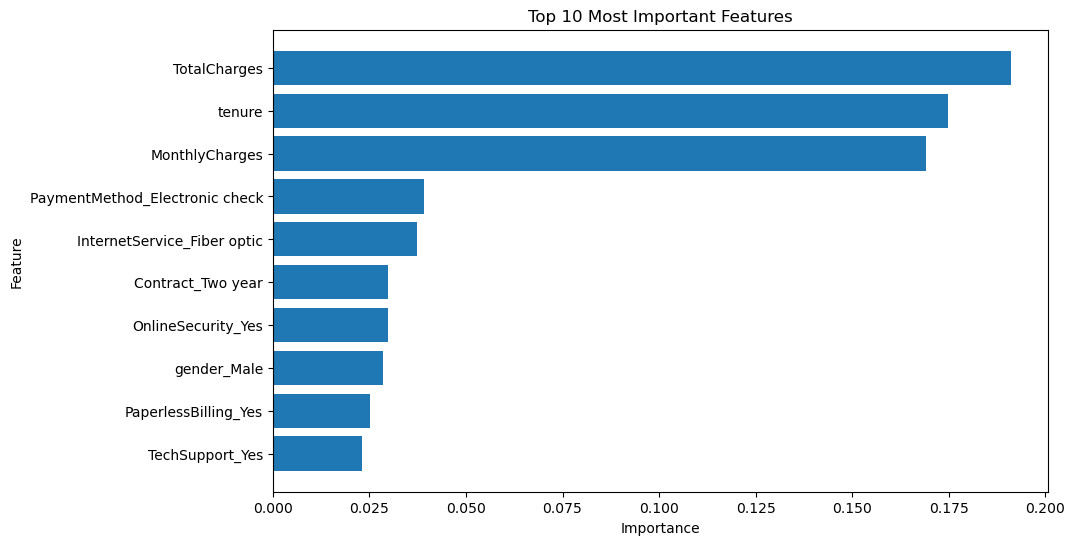

In [61]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 10 Most Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.gca().invert_yaxis()

plt.savefig(
    'feature_importance.png',
    bbox_inches='tight'
)

plt.show()

## 11. Business Recommendations

The following recommendations are based on the insights obtained from exploratory data analysis and machine learning models.

1. Focus retention efforts on new customers during their first year.

2. Encourage customers to move from month-to-month contracts to longer-term contracts.

3. Monitor customers with high monthly charges and provide personalized retention offers.

4. Promote value-added services such as Online Security and Technical Support.

5. Identify high-risk customers early and engage them proactively.

## 12. Conclusion

This project developed machine learning models to predict customer churn using the IBM Telco Customer Churn dataset.

After comparing multiple models, Scaled Logistic Regression achieved the best performance with an accuracy of approximately 80.7%.

The analysis revealed that customer tenure, monthly charges, total charges, contract type, and service usage are key drivers of churn.

These insights can help businesses improve customer retention strategies and reduce revenue loss due to customer attrition.